In [145]:
#这里测试RHPPO,PPO,METAPPO 在切换的场景下的决策效果对比，以及数据记录

import numpy as np
import pandas as pd
import math
import time
import random
import matplotlib.pyplot as plt
import pickle

from collections import defaultdict,namedtuple,deque
import copy
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

import torch
import BSS_ENV_shortduration as BE
import BSS_MODEL as BM

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [146]:
class options:
    def __init__(self,num):
        self.charger_num = num
        self.ev_num = num
        self.bssbatterynum = 2 * num
        self.maxpve = 0
        self.transit_step = 2
        self.ev_average_worksoc = 0.1

        self.inp_dim = 4
        self.memory_count = 1000
        self.GAMMA = 0.99
        self.beta = 0.2
        self.MEMORY_NUM = 3
        self.game_step = 400
        
        self.NUM_EPISODES = 2500

        self.update_gamecount = 4#每进行多少轮游戏更新网络

        self.learning_ratio = 0.001
        self.if_clamp = True
        self.modelpath = r'data\modeldata'
        self.dirpath=r'XXXXX'# Project path
        self.gru_state = r'data\gru.pth'
        self.price_data = r'data\pricedata.csv'
        #模型的初始化格式
        self.pit = {'avg':0,'ban':1,'all':2}#等概率考虑pv，不使用pv，最大化使用pv

OPTIONS = options(10)

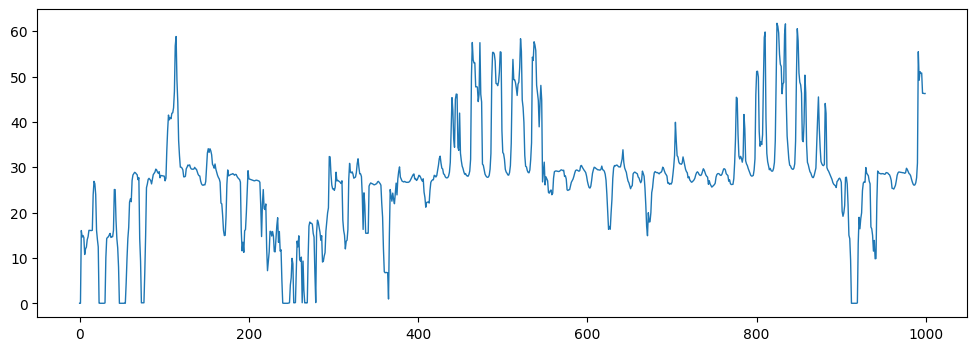

In [147]:
price_data_path = OPTIONS.price_data
pd_frame = pd.read_csv(price_data_path)

DK_1_price = pd_frame['DK_1_price_day_ahead']
DK_1_price.fillna(0,inplace=True)

DK_1_price_nparray =np.array([max(0,i) for i in DK_1_price.tolist()])

fig, ax = plt.subplots(figsize = (12,4))
ax.plot(np.arange(1000), DK_1_price_nparray[0:1000], linewidth=1)
plt.show()

In [148]:
GM = BE.GameManager(OPTIONS,ps_eprice_ds=DK_1_price_nparray)
def StateTensor(gm:BE.GameManager):
    bt1_num,bt2_num,b_num,energy_cost,carbon,bssevqueue_length,wasted_reserve,ctime,is_done = gm.EnvState()
    ctime = ctime/10 #
    statetensor = torch.tensor([bt1_num,bt2_num,bssevqueue_length,ctime],dtype= torch.float32).to(device)
    costtensor = torch.tensor([energy_cost,bssevqueue_length,wasted_reserve],dtype= torch.float32).to(device)
    return statetensor.unsqueeze(0),costtensor.unsqueeze(0) #1*4 ,1*3

cfactor_t1 = 0.05
qfactor_t1 = 1
wfactor_t1 = 0.5
def rewardtype1(cost_T,opts:options):#

    charging_cost = cfactor_t1* cost_T[:,0]/120#

    emergenceqfactor = 1 if opts.ev_num/cost_T[:,1]>1.5 else 3
    evqueuetimein_bss = qfactor_t1*(cost_T[:,1])*emergenceqfactor

    wast_request = wfactor_t1*cost_T[:,2]

    bss_reward = -(evqueuetimein_bss+ wast_request+charging_cost)/opts.ev_num

    bss_reward = bss_reward.unsqueeze(0) #
    return bss_reward


def rewardtype1_detail(cost_T,opts:options):#

    charging_cost = cfactor_t1* cost_T[:,0]/120#

    emergenceqfactor = 1 if opts.ev_num/cost_T[:,1]>1.5 else 3
    evqueuetimein_bss = qfactor_t1*(cost_T[:,1])*emergenceqfactor

    wast_request = wfactor_t1*cost_T[:,2]

    bss_reward = -(evqueuetimein_bss+ wast_request+charging_cost)/opts.ev_num

    bss_reward = bss_reward.unsqueeze(0) #
    return bss_reward,-charging_cost,-evqueuetimein_bss,-wast_request

In [149]:
import copy#深度复制，确保两条路线不会相互干扰
#这里额外采集一些策略的路径用于训练的补充

bssreward = rewardtype1

modelemf050 = BM.BSS_DRL_SINGLEACT(OPTIONS)
modelemf050path =os.path.join(OPTIONS.modelpath,'PPO_emgfactor050v1_SCALE10_singleact.pth')
modelemf050.bss_agent.load_state_dict(torch.load(modelemf050path))

# modelemf075 = BM.BSS_DRL_SINGLEACT(OPTIONS)
# modelemf075path =os.path.join(OPTIONS.modelpath,'PPO_emgfactor075v1_SCALE10_singleact.pth')
# modelemf075.bss_agent.load_state_dict(torch.load(modelemf075path))

modelemf100 = BM.BSS_DRL_SINGLEACT(OPTIONS)
modelemf100path =os.path.join(OPTIONS.modelpath,'PPO_emgfactor100v1_SCALE10_singleact.pth')
modelemf100.bss_agent.load_state_dict(torch.load(modelemf100path))

# modelemf125 = BM.BSS_DRL_SINGLEACT(OPTIONS)
# modelemf125path =os.path.join(OPTIONS.modelpath,'PPO_emgfactor125v1_SCALE10_singleact.pth')
# modelemf125.bss_agent.load_state_dict(torch.load(modelemf125path))

modelemf150 = BM.BSS_DRL_SINGLEACT(OPTIONS)
modelemf150path =os.path.join(OPTIONS.modelpath,'PPO_emgfactor150v1_SCALE10_singleact.pth')
modelemf150.bss_agent.load_state_dict(torch.load(modelemf150path))

# modelemf175 = BM.BSS_DRL_SINGLEACT(OPTIONS)
# modelemf175path =os.path.join(OPTIONS.modelpath,'PPO_emgfactor175v1_SCALE10_singleact.pth')
# modelemf175.bss_agent.load_state_dict(torch.load(modelemf175path))

modelemf200 = BM.BSS_DRL_SINGLEACT(OPTIONS)
modelemf200path =os.path.join(OPTIONS.modelpath,'PPO_emgfactor200v1_SCALE10_singleact.pth')
modelemf200.bss_agent.load_state_dict(torch.load(modelemf200path))
class Emergence_model:
    def __init__(self,ef,model):
        self.emergencefactor = ef
        self.model = model

model_set = [modelemf050,modelemf100,modelemf150,modelemf200]#,modelemf175] 
model_BOX = [Emergence_model(0.5,modelemf050),Emergence_model(1,modelemf100),\
             Emergence_model(1.5,modelemf150),Emergence_model(2,modelemf200)]
# model_BOX = [Emergence_model(0.5,modelemf05),\
#              Emergence_model(1.5,modelemf150)]
              

In [150]:
class StrategyPICK(torch.nn.Module):
    def __init__(self, durationdim=8, inpdim=4, tragy_classes=3):
        super(StrategyPICK,self).__init__()
        self.inplayer = torch.nn.Linear(durationdim*inpdim,64).to(device)
        self.line1 = torch.nn.Linear(64,128).to(device)
        self.line2 = torch.nn.Linear(128,64).to(device)
        self.line3 = torch.nn.Linear(64,tragy_classes).to(device)
        
    def forward(self, x):
        inpx = x.to(device)
        x_flat = torch.nn.Flatten()(inpx )

        xinplayer = self.inplayer(x_flat)
        xrelu1 = torch.nn.ReLU()(xinplayer)
        xdrop1 =torch.nn.Dropout(0.5)(xrelu1)
        xline1 = self.line1(xdrop1)
        xrelu2 = torch.nn.ReLU()(xline1)

        xline2 = self.line2(xrelu2)
        xline3 = self.line3(xline2)

        res = xline3
        return res


In [151]:
pickmodel1 = StrategyPICK(durationdim=16,inpdim=4, tragy_classes=4)

kickmodel_dir = r'data\modeldata'
pick1model_path = os.path.join(kickmodel_dir,'pick1modelv1_singleact_4typev2.pth')
# pick2model_path = os.path.join(kickmodel_dir,'pick2modelv1.pth')
# kickmodel_path = os.path.join(kickmodel_dir,'kickmodelv1.pth')

pick1model_statedict = torch.load(pick1model_path)
pickmodel1.load_state_dict(pick1model_statedict)


<All keys matched successfully>

In [152]:
emergence_set = [0.5,1,1.5,2] 
model_set = [modelemf050,modelemf100,modelemf150,modelemf200]
modelselects =  [0,1,2,3]

startid = 1
secid = 3

In [ ]:
def init_records():
    return defaultdict(list)

def record_step(records, gamemanager, reserve_act, rew, rcost, rqueue, rwast):
    records["request_reserve"].append(reserve_act)
    records["request_energy"].append(gamemanager.stage_used_energy)
    records["wait_nums"].append(gamemanager.bss_queuelength)
    records["ava_bs"].append(gamemanager.ava_bnum)
    records["gprices"].append(gamemanager.ps.price)
    records["rew"].append(rew.cpu().item())
    records["rcost"].append(rcost.cpu().item())
    records["rqueue"].append(rqueue.cpu().item())
    records["rwast"].append(rwast.cpu().item())
    records["readybT1s"].append(gamemanager.bss.BT1_readdy_num)
    records["readybT2s"].append(gamemanager.bss.BT2_readdy_num)

def select_reserve_action(model, state, opt):
    if model is None:
        return opt.charger_num / 2

    _, prob = model.select_action(state)
    return prob.argmax().cpu().item()

def update_model_if_needed(i, start_kick, inptimelength, statedeque, modelset, pickmodel1, currentmodel):
    if i != start_kick + int(inptimelength / 2):
        return currentmodel, False

    kick_state = torch.cat(list(statedeque), dim=0)
    pick_res = pickmodel1(kick_state.unsqueeze(0))
    pick_index = torch.argmax(torch.nn.Softmax(dim=-1)(pick_res)).cpu().item()

    print(f"Selected model index: {pick_index}")
    return modelset[pick_index], True

def plot_records(records, gamestep):
    def plotax(ax, x, y_list, names):
        lines = []
        for y in y_list:
            line, = ax.plot(x, y)
            lines.append(line)
        ax.legend(lines, names)

    fig, axs = plt.subplots(5, 1, figsize=(12, 12))
    x = range(gamestep)

    plotax(axs[0], x, [records["request_reserve"]], ["request_reserve"])
    plotax(axs[1], x, [records["wait_nums"], records["ava_bs"]], ["wait_nums", "ava_bs"])
    plotax(axs[2], x, [records["gprices"]], ["gprices"])
    plotax(axs[3], x, [records["readybT1s"], records["readybT2s"]], ["readybT1s", "readybT2s"])
    plotax(axs[4], x, [records["rcost"], records["rqueue"], records["rwast"]], ["rcost", "rqueue", "rwast"])

    plt.tight_layout()
    plt.show()


def test1(step, gamemanager,rewardF,opt,emgfset,emgid1,emgid2,modelset=model_set,pickmodel1=pickmodel1,showmessage=False,plot=True):
    gamemanager.Initial(reinitial=True)
    print("simulation start")
    gamemanager.Message()

    records = init_records()
    rewards = 0

    inptimelength = 16
    statedeque = deque([], maxlen=inptimelength)

    start_kick = random.randint(150, 250)
    dyemergencefactor = emgfset[emgid1]
    currentmodel = modelset[emgid1]
    endrecord = False

    for i in range(step):

        if i == start_kick:
            dyemergencefactor = emgfset[emgid2]
            print(f"At stage {i}, environment changes. "
                f"Initial emergency factor: {emgfset[emgid1]}, "
                f"new emergency factor: {emgfset[emgid2]}"
            )

        currentmodel, model_changed = update_model_if_needed(i, start_kick, inptimelength, statedeque, modelset, pickmodel1, currentmodel)

        if model_changed:
            endrecord = True

        csta, _ = StateTensor(gamemanager)

        reserve_act = select_reserve_action(currentmodel, csta, opt)

        gamemanager.Update(reserve_act,chargeplan=0,emergencefactor=dyemergencefactor,showmessages=showmessage)

        nsta, ncost = StateTensor(gamemanager)
        rew, rcost, rqueue, rwast = rewardF(ncost, opt)

        rewards += rew
        record_step(records, gamemanager, reserve_act, rew, rcost, rqueue, rwast)

        if showmessage:
            gamemanager.Message()

        if not endrecord:
            statedeque.append(nsta.detach())

    if plot:
        plot_records(records, step)

    return records["rew"]

simulation start
Environment information at the end of time 0 is as follows
At the end of the current time step, the number of EVs in the working state is 10, and the number of EVs queued at the station is 0
In the station, available full-charge batteries: 20, 80%-charge batteries: 0, queued EVs: 0


At stage 179, environment changes. Initial emergency factor: 0.5, new emergency factor: 2
Selected model index: 3


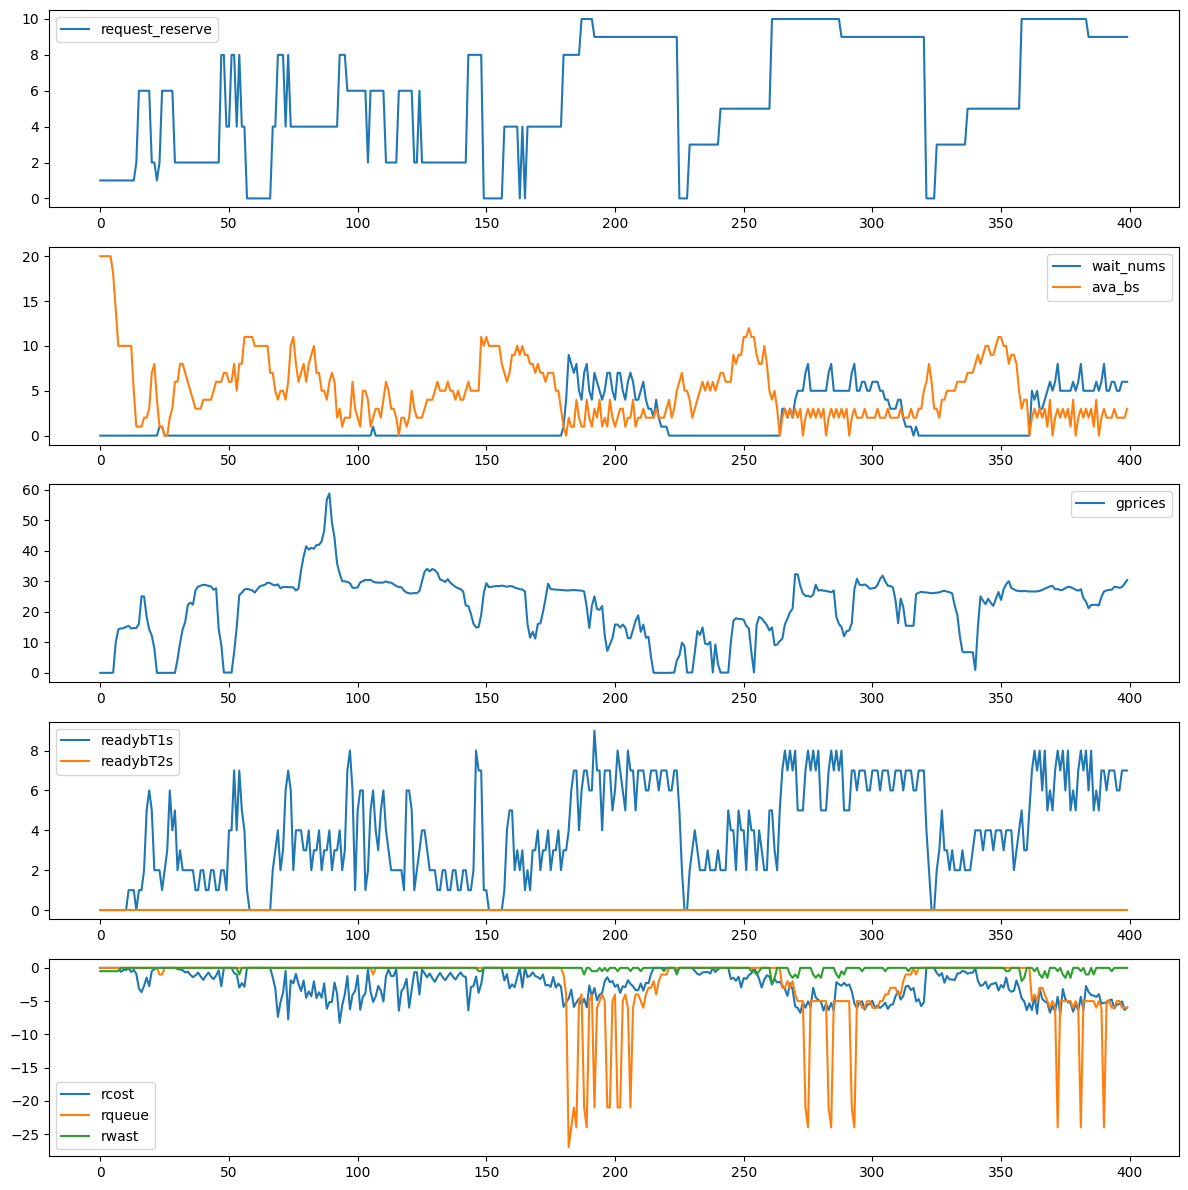

-204.57617381151067

In [168]:
rews =test1(400,gamemanager=GM,rewardF=rewardtype1_detail,opt= OPTIONS,emgfset=emergence_set,emgid1=0,emgid2=3)
sum(rews)